# EDA — World Bank

Phân tích `world_bank.json`: loại nội dung, mức độ thiếu ngày xuất bản, chất lượng dữ liệu, độ dài bài và mẫu bản ghi.

In [1]:
from pathlib import Path
import sys
search_roots = (Path.cwd(), *Path.cwd().parents)
module_dir = next((p for root in search_roots for p in (root, root / "loc_crawl" / "notebooks") if (p / "eda_utils.py").exists()), None)
if module_dir is None: raise FileNotFoundError("Không tìm thấy eda_utils.py")
sys.path.insert(0, str(module_dir))

from eda_utils import *
SOURCE_KEY = "world_bank"
df, atomic_domains, data_path = load_source(SOURCE_KEY)
print(f"Đã tải {len(df):,} bài từ {data_path}")

Đã tải 1,400 bài từ C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output_news\world_bank.json


## 1. Tổng quan và mẫu dữ liệu

In [2]:
overview = source_overview(df, atomic_domains, data_path)

**File:** `C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output_news\world_bank.json`  
**Kích thước:** 6.03 MB

,Chỉ số,Giá trị
0,Số bài,"1,400"
1,Số domain nguyên bản,6
2,Số domain sau khi tách,6
3,Bài đa-domain,0
4,Ngày hợp lệ,0 (0.0%)
5,Ngày nhỏ nhất,—
6,Ngày lớn nhất,—
7,ID trùng,0
8,URL trùng,0


,id,source_name,domain,publish_date,claim,label,url
0,c85c30dbc0b189cb8fcb47ec263429b1,World Bank,Opinions,,Panama’s challenge: growing with the best human talent,TRUE,https://www.worldbank.org/en/news/opinion/2026/03/04/el-desafio-panama-crecer-con-mejor-talento-...
1,8685bf6905a3357b7b62222517b7368c,World Bank,Opinions,,Interview With World Bank Group Country Manager Massimiliano Paolucci on Albania’s Reforms as Ke...,TRUE,https://www.worldbank.org/en/news/opinion/2026/01/13/interview-with-world-bank-group-country-man...
2,701f179dca5d5e54d0f9579fb3e0dd38,World Bank,Opinions,,Turning Recovery into Readiness in Sint Maarten,TRUE,https://www.worldbank.org/en/news/opinion/2025/12/08/turning-recovery-into-readiness-in-sint-maa...
3,fda2ee1cf66731c7ebf66c075a699edb,World Bank,Opinions,,Passing the Test: Hurricane Melissa and the Caribbean’s Resilience,TRUE,https://www.worldbank.org/en/news/opinion/2025/12/03/passing-the-test-hurricane-melissa-and-the-...
4,2d54b9da3391cac2eed71ab933e38d54,World Bank,Opinions,,"On the Road to Building Safer, More Inclusive and Resilient Transport in Guyana",TRUE,https://www.worldbank.org/en/news/opinion/2025/11/27/on-the-road-to-building-safer-more-inclusiv...


## 2. Phân bố domain

**Phân bố domain sau khi tách dấu `;`**

,domain,số_bài,tỷ_lệ_trên_bài
0,Press Releases,853,0.61
1,Features,446,0.32
2,Statements,33,0.02
3,Opinions,24,0.02
4,Fact Sheets,22,0.02
5,Speeches,22,0.02


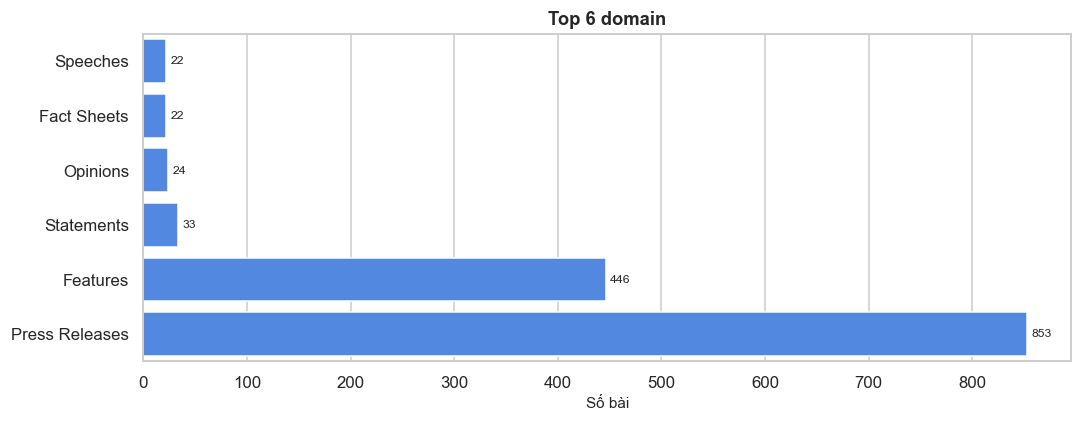

In [3]:
domain_counts = source_domain_analysis(df, atomic_domains)

## 3. Phân bố thời gian và domain theo năm

In [4]:
source_timeline(df, atomic_domains)

,trạng_thái_ngày,số_bài,tỷ_lệ
0,Hợp lệ,0,0.00
1,Thiếu/không parse được,1400,1.00


> Không có `publish_date` hợp lệ nên bỏ qua biểu đồ thời gian.

## 4. Chất lượng dữ liệu

,field,missing,missing_pct
0,comments,1400,100.00
1,publish_date,1400,100.00
2,claim,0,0.00
3,domain,0,0.00
4,evidence,0,0.00
5,id,0,0.00
6,justification,0,0.00
7,label,0,0.00
8,original_text,0,0.00
9,source_name,0,0.00


**Trùng lặp và URL**

,khóa,số_dòng_trùng,số_giá_trị_duy_nhất
0,id,0,1400
1,url,0,1400
2,claim,3,1397
3,original_text,3,1397


,chỉ_số,số_bài
0,URL HTTP(S) hợp lệ,1400
1,URL không hợp lệ/thiếu,0
2,Ngày ở tương lai so với hôm nay,0
3,Bài có comments,0


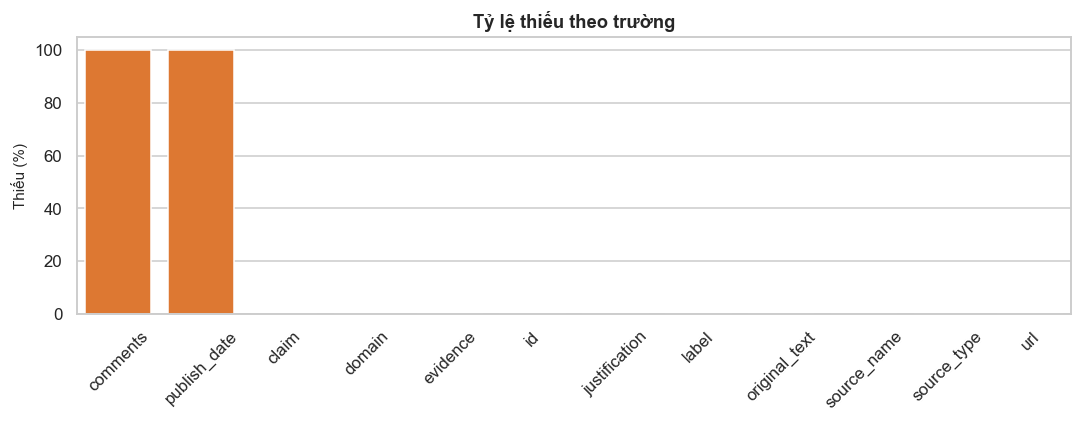

In [5]:
missing = source_quality_analysis(df)

## 5. Độ dài nội dung

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
trường,,,,,,,,,,,
claim_words,"1,400.00",12.10,3.68,2.00,9.00,12.00,14.00,17.00,18.00,22.00,25.00
original_text_words,"1,400.00",45.23,52.84,1.00,25.00,37.00,52.00,73.00,91.00,132.05,889.00
evidence_words,"1,400.00",8.00,0.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00
justification_words,"1,400.00",511.16,284.35,29.00,343.00,461.50,614.75,809.00,939.10,"1,528.71","3,543.00"


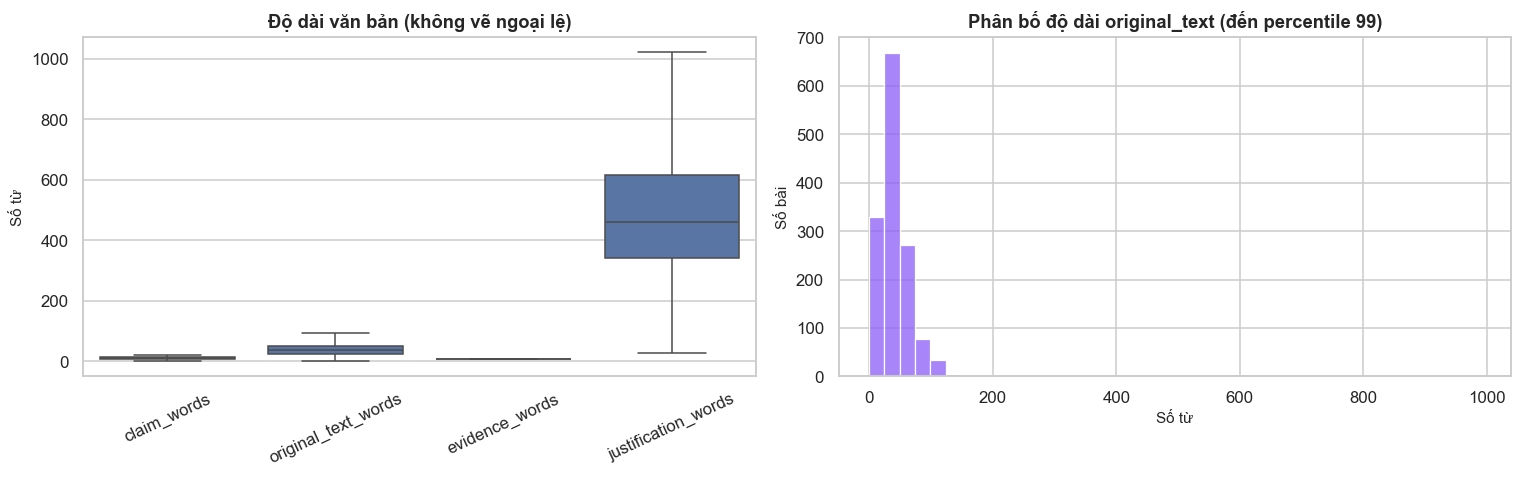

**Độ dài `original_text` theo top domain**

,số_bài,trung_vị,trung_bình,p90
domain_atomic,,,,
Fact Sheets,22,42.00,65.55,102.80
Press Releases,853,38.00,47.96,71.00
Statements,33,38.00,38.70,57.60
Features,446,34.00,40.83,75.00
Opinions,24,30.50,32.71,50.80
Speeches,22,24.00,31.45,59.80


In [6]:
text_summary = source_text_analysis(df, atomic_domains)

## 6. Nhãn, loại nguồn và hostname

In [7]:
source_metadata_analysis(df)

**Nhãn**

,label,số_bài,tỷ_lệ
0,TRUE,1400,1.00


**Loại nguồn**

,source_type,số_bài,tỷ_lệ
0,website,1400,1.00


**Tên nguồn**

,source_name,số_bài,tỷ_lệ
0,World Bank,1400,1.00


**Hostname**

,url_host,số_bài,tỷ_lệ
0,worldbank.org,1400,1.00


## 7. Mẫu bài theo domain và nhận xét

In [8]:
samples = source_samples(df, n_per_domain=2)
source_findings(df, atomic_domains)

,domain,publish_date,claim,label,url
0,Fact Sheets,,Factsheet on World Bank support for the Democratic Republic of Congo’s Inga Project,TRUE,https://www.worldbank.org/en/news/factsheet/2024/10/09/questions-and-answers-on-world-bank-suppo...
1,Fact Sheets,,The Advancing Innovative Methods to Promote Learning (AIM4Learning) Program: Comoros,TRUE,https://www.worldbank.org/en/news/factsheet/2025/02/20/the-advancing-innovative-methods-to-promo...
2,Features,,Accelerating Learning for A More Food Secure Future Across Eastern and Southern Africa,TRUE,https://www.worldbank.org/en/news/feature/2025/04/28/accelerating-learning-for-a-more-food-secur...
3,Features,,Ensuring a Brighter Future for Ukraine’s Smallholder Farmers,TRUE,https://www.worldbank.org/en/news/feature/2025/10/22/ensuring-brighter-future-for-ukraines-small...
4,Opinions,,"Integration of Migrants, Refugees, and Returnees: A Driver for Improving Well-being and the Economy",TRUE,https://www.worldbank.org/en/news/opinion/2024/12/16/integracion-migrantes-refugiados-retornados...
5,Opinions,,Closing the Skills Gap to Create More Jobs in the Caribbean,TRUE,https://www.worldbank.org/en/news/opinion/2025/06/26/closing-the-skills-gap-to-create-more-jobs-...
6,Press Releases,,World Bank Enhances Commitment to Human Capital Development in Morocco,TRUE,https://www.worldbank.org/en/news/press-release/2025/03/19/world-bank-enhances-commitment-to-hum...
7,Press Releases,,"East Asia and Pacific: Technology, Reforms, and Cooperation Pathways to Future Prosperity",TRUE,https://www.worldbank.org/en/news/press-release/2025/04/24/east-asia-and-pacific-technology-refo...
8,Speeches,,World Bank Administrative Tribunal – Opening Remark,TRUE,https://www.worldbank.org/en/news/speech/2025/11/17/world-bank-administrative-tribunal-opening-r...
9,Speeches,,"Remarks by Anna Bjerde, World Bank Managing Director of Operations, at the Ukraine Recovery Conf...",TRUE,https://www.worldbank.org/en/news/speech/2025/07/10/remarks-by-anna-bjerde-world-bank-managing-d...


### Nhận xét tự động
- Có **1,400** bài và **6** domain sau khi tách.
- Domain lớn nhất là **Press Releases** với **853** lượt gán.
- Có **0** bài đa-domain và **1,400** bài thiếu/không parse được ngày.
- Phân bố nhãn: **TRUE: 1,400**.
- Các nhận xét này là mô tả dữ liệu, không phải kết luận về tính đại diện hay chất lượng nội dung.